In [40]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold  #necessary to train/split the data, GridSearchCV to find the optimal hyperparameters, and kfold to optimize the data
from sklearn.preprocessing import StandardScaler, OneHotEncoder # preprocessing to standarize the features
from sklearn.compose import ColumnTransformer # allows different transformers for the dataset
from sklearn.pipeline import Pipeline # Preprocessing to manage the workflow

from sklearn.linear_model import LogisticRegression # Model
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_curve # Metrics

In [2]:
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [4]:

competition_path = kagglehub.competition_download("playground-series-s6e2") # dowloading the dataset from kaggle
print(os.listdir(competition_path))

100%|██████████| 10.2M/10.2M [00:00<00:00, 12.0MB/s]

Extracting files...


['train.csv', 'sample_submission.csv', 'test.csv']


In [5]:
train_df = pd.read_csv(os.path.join(competition_path, 'train.csv')) # loading data set in panda data frame
test_df = pd.read_csv(os.path.join(competition_path, 'test.csv'))
sample_sub = pd.read_csv(os.path.join(competition_path, 'sample_submission.csv'))
print(train_df.info())
print(train_df.head())
print(train_df.shape)
print(test_df.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [6]:
train_df['Heart Disease'].value_counts(normalize=True)

,proportion
Heart Disease,
Absence,0.55166
Presence,0.44834


In [22]:
categorical_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'Thallium']
numerical_cols = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro']
# seperating the features into categorical columns and numerical columns for preprocessing

X = train_df.drop(columns=['Heart Disease', 'id'])
y = train_df['Heart Disease']
X_test = test_df.drop(columns=['id'])

In [24]:
preprocessor = ColumnTransformer([ # Formatting the columns appropriately
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

In [25]:
pipeline = Pipeline([ #Applying transformers and etimator
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs'))
])

In [26]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, # splitting the data into training and validaiton sets
                                                  random_state=42, stratify=y)

In [27]:
param_grid = { #defining hyperparameters
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs', 'newton-cg']
}

grid = GridSearchCV(pipeline, param_grid, cv=StratifiedKFold(5), #Initialize GridSearch
                    scoring='roc_auc', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train) # Training and looking for the best verion

print("\nBest parameters:", grid.best_params_)
print("Best cross-validation ROC-AUC:", grid.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best parameters: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'newton-cg'}
Best cross-validation ROC-AUC: 0.9530050458574297


In [34]:
best_model = grid.best_estimator_ #Best performing parameters with logistic regression model
y_pred = best_model.predict(X_val) # class predictions
y_proba = best_model.predict_proba(X_val)[:, 1] # Needed for ROC-AUC to predict positive classes

acc = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred, pos_label='Presence')
rec = recall_score(y_val, y_pred, pos_label='Presence')
f1 = f1_score(y_val, y_pred, pos_label='Presence')

y_val_binary = y_val.map({'Presence': 1, 'Absence': 0}) # Numerical format needed so converted to numerical values
roc_auc = roc_auc_score(y_val_binary, y_proba)

print("\n=== Validation Performance ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



=== Validation Performance ===
Accuracy:  0.8881
Precision: 0.8841
Recall:    0.8636
F1-score:  0.8737
ROC-AUC:   0.9543


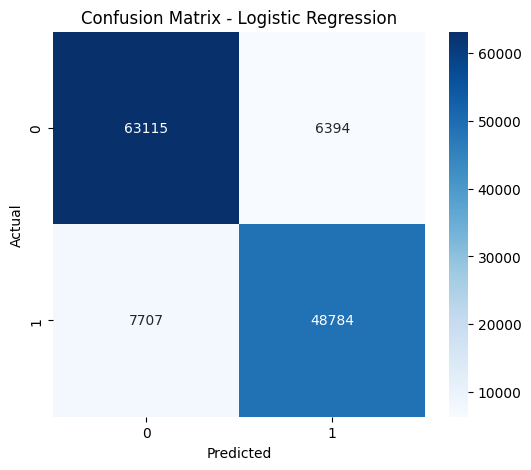

In [38]:
m = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(m, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

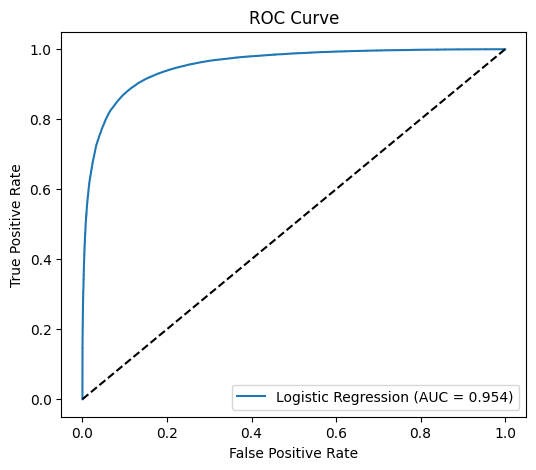

In [42]:
fpr, tpr, _ = roc_curve(y_val_binary, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()